In [1]:
import sys
print(sys.executable)


C:\Users\jasti\anaconda3\envs\msml\python.exe


In [2]:
import mlflow
print(mlflow.__version__)


2.19.0


In [3]:
import os
os.chdir(r"C:\Users\jasti\SMSML_Latihan\preprocessing")
print("Sekarang di folder:", os.getcwd())

Sekarang di folder: C:\Users\jasti\SMSML_Latihan\preprocessing


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd

# load dataset
df = pd.read_csv("../namadataset_raw/covid_19_indonesia_time_series_all.csv")

# lihat ukuran & 5 baris pertama
print("Jumlah baris, kolom:", df.shape)
df.head()

Jumlah baris, kolom: (31822, 38)


,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,...,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,NaN,NaN
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,...,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.0,1.0
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0,0,...,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
3,3/2/2020,ID-RI,Riau,1,0,0,1,1,0,1,...,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,NaN,NaN
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,...,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.0,1.0


In [6]:
print(df.columns.tolist())
df.info()

['Date', 'Location ISO Code', 'Location', 'New Cases', 'New Deaths', 'New Recovered', 'New Active Cases', 'Total Cases', 'Total Deaths', 'Total Recovered', 'Total Active Cases', 'Location Level', 'City or Regency', 'Province', 'Country', 'Continent', 'Island', 'Time Zone', 'Special Status', 'Total Regencies', 'Total Cities', 'Total Districts', 'Total Urban Villages', 'Total Rural Villages', 'Area (km2)', 'Population', 'Population Density', 'Longitude', 'Latitude', 'New Cases per Million', 'Total Cases per Million', 'New Deaths per Million', 'Total Deaths per Million', 'Total Deaths per 100rb', 'Case Fatality Rate', 'Case Recovered Rate', 'Growth Factor of New Cases', 'Growth Factor of New Deaths']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31822 entries, 0 to 31821
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         31822 non-null  object 
 1   Locat

In [7]:
df.isnull().sum().sort_values(ascending=False)

City or Regency                31822
Special Status                 27264
Growth Factor of New Deaths     3447
Growth Factor of New Cases      1939
Total Rural Villages             929
Island                           929
Time Zone                        929
Province                         929
Total Urban Villages             904
Total Cities                     901
Location ISO Code                  0
Date                               0
New Cases                          0
Location                           0
New Recovered                      0
New Deaths                         0
Total Deaths                       0
Total Recovered                    0
Total Active Cases                 0
Location Level                     0
New Active Cases                   0
Total Cases                        0
Total Districts                    0
Total Regencies                    0
Continent                          0
Country                            0
Population Density                 0
L

In [8]:
df.describe()

,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,Total Active Cases,City or Regency,Total Regencies,...,Population Density,Longitude,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Growth Factor of New Cases,Growth Factor of New Deaths
count,31822.000000,31822.000000,31822.000000,31822.000000,3.182200e+04,31822.000000,3.182200e+04,31822.000000,0.0,31822.000000,...,31822.000000,31822.000000,31822.000000,31822.000000,31822.000000,31822.000000,31822.000000,31822.000000,29883.000000,28375.000000
mean,402.311388,9.920652,390.398498,1.992238,1.594500e+05,4564.753221,1.492615e+05,5623.782415,NaN,24.027277,...,738.894928,113.700478,-2.725681,28.133292,11485.038800,0.640308,289.633640,28.963329,1.326795,1.033834
std,2320.629838,64.139080,2199.878802,1219.513355,6.264435e+05,17693.731369,5.958536e+05,28537.412305,NaN,68.359734,...,2729.431626,9.862068,3.608065,74.309710,16477.385479,1.933016,363.428724,36.342881,2.679379,1.351755
min,0.000000,0.000000,0.000000,-29938.000000,1.000000e+00,0.000000,0.000000e+00,-2343.000000,NaN,1.000000,...,8.590000,96.910522,-8.682205,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,2.000000,-12.000000,5.223250e+03,128.000000,3.913500e+03,80.000000,NaN,7.000000,...,47.790000,106.109004,-6.204699,0.830000,1291.367500,0.000000,38.862500,3.890000,0.650000,0.750000
50%,27.000000,0.000000,20.000000,0.000000,2.359650e+04,565.500000,2.102750e+04,557.000000,NaN,11.000000,...,103.840000,113.417654,-2.461746,5.710000,6804.285000,0.000000,158.415000,15.840000,1.000000,1.000000
75%,130.000000,3.000000,123.000000,19.000000,6.992775e+04,2189.000000,6.414200e+04,2279.000000,NaN,18.000000,...,262.700000,121.201093,0.212037,22.290000,14557.360000,0.540000,389.910000,38.990000,1.310000,1.000000
max,64718.000000,2069.000000,61361.000000,39165.000000,6.405044e+06,157876.000000,6.218708e+06,586113.000000,NaN,416.000000,...,16334.310000,138.696030,4.225615,1459.040000,130231.620000,63.800000,1632.600000,163.260000,175.000000,134.500000


In [9]:
df.isnull().sum()[df.isnull().sum() > 0]

City or Regency                31822
Province                         929
Island                           929
Time Zone                        929
Special Status                 27264
Total Cities                     901
Total Urban Villages             904
Total Rural Villages             929
Growth Factor of New Cases      1939
Growth Factor of New Deaths     3447
dtype: int64

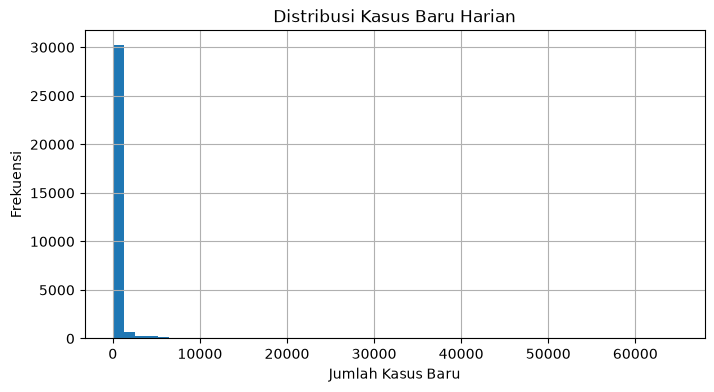

In [10]:
import matplotlib.pyplot as plt

df["New Cases"].hist(bins=50, figsize=(8,4))
plt.title("Distribusi Kasus Baru Harian")
plt.xlabel("Jumlah Kasus Baru")
plt.ylabel("Frekuensi")
plt.show()

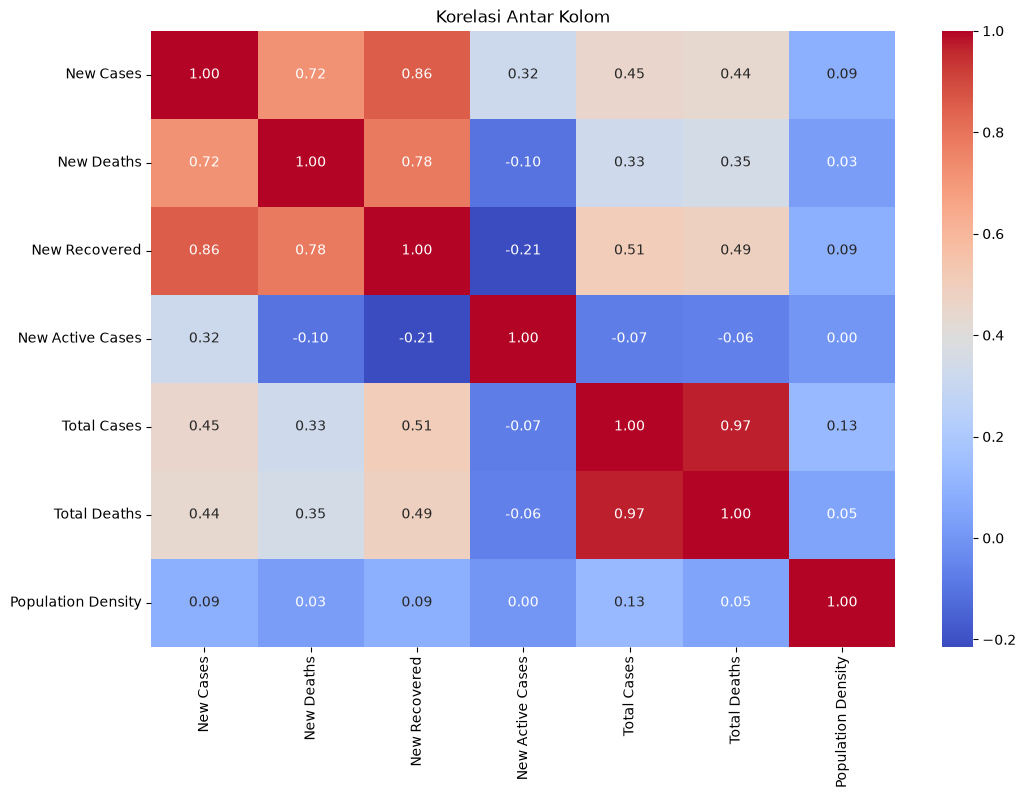

In [11]:
import seaborn as sns

plt.figure(figsize=(12,8))
corr = df[["New Cases", "New Deaths", "New Recovered", "New Active Cases", 
           "Total Cases", "Total Deaths", "Population Density"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Antar Kolom")
plt.show()

In [12]:
print(df["Location"].nunique(), "lokasi unik")
df["Location"].value_counts().head(10)

35 lokasi unik


Location
DKI Jakarta                   929
Indonesia                     929
Riau                          928
Jawa Barat                    927
Banten                        924
Jawa Tengah                   922
Sulawesi Tenggara             920
Bali                          919
Kalimantan Timur              916
Daerah Istimewa Yogyakarta    914
Name: count, dtype: int64

In [13]:
import numpy as np

# bikin kategori risiko berdasarkan jumlah kasus baru
def kategori_risiko(new_cases):
    if new_cases < 10:
        return "Rendah"
    elif new_cases < 100:
        return "Sedang"
    else:
        return "Tinggi"

df["Kategori_Risiko"] = df["New Cases"].apply(kategori_risiko)

# cek distribusi kategori barunya
df["Kategori_Risiko"].value_counts()

Kategori_Risiko
Rendah    11614
Sedang    10991
Tinggi     9217
Name: count, dtype: int64

In [14]:
# pilih fitur yang mau dipakai
fitur_dipakai = [
    "New Deaths", "New Recovered", "New Active Cases",
    "Population Density", "Population", "Area (km2)",
    "Case Fatality Rate", "Case Recovered Rate",
    "Kategori_Risiko"  # ini target-nya
]

df_model = df[fitur_dipakai].copy()
df_model.head()

,New Deaths,New Recovered,New Active Cases,Population Density,Population,Area (km2),Case Fatality Rate,Case Recovered Rate,Kategori_Risiko
0,0,0,2,16334.31,10846145,664,51.28%,192.31%,Rendah
1,0,0,2,16334.31,10846145,664,48.78%,182.93%,Rendah
2,0,0,2,138.34,265185520,1916907,0.00%,0.00%,Rendah
3,0,0,1,69.80,6074100,87024,0.00%,100.00%,Rendah
4,0,0,2,16334.31,10846145,664,46.51%,174.42%,Rendah


In [15]:
print("Missing value sebelum handling:")
print(df_model.isnull().sum())

# hapus baris yang ada missing value (karena porsinya kecil dari total data)
df_model = df_model.dropna()

print("\nJumlah baris setelah dropna:", len(df_model))

Missing value sebelum handling:
New Deaths             0
New Recovered          0
New Active Cases       0
Population Density     0
Population             0
Area (km2)             0
Case Fatality Rate     0
Case Recovered Rate    0
Kategori_Risiko        0
dtype: int64

Jumlah baris setelah dropna: 31822


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model["Kategori_Risiko_Encoded"] = le.fit_transform(df_model["Kategori_Risiko"])

# cek mapping-nya biar tau angka berapa = kategori apa
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Rendah': np.int64(0), 'Sedang': np.int64(1), 'Tinggi': np.int64(2)}


In [17]:
X = df_model.drop(columns=["Kategori_Risiko", "Kategori_Risiko_Encoded"])
y = df_model["Kategori_Risiko_Encoded"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (31822, 8)
Shape y: (31822,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (25457, 8) Test: (6365, 8)


In [45]:
# bersihkan kolom yang formatnya string persen jadi angka desimal
for kolom in ["Case Fatality Rate", "Case Recovered Rate"]:
    df[kolom] = df[kolom].astype(str).str.replace("%", "", regex=False)
    df[kolom] = pd.to_numeric(df[kolom], errors="coerce") / 100

print(df[["Case Fatality Rate", "Case Recovered Rate"]].head())


   Case Fatality Rate  Case Recovered Rate
0            0.005128             0.019231
1            0.004878             0.018293
2            0.000000             0.000000
3            0.000000             0.010000
4            0.004651             0.017442


In [46]:
fitur_dipakai = [
    "New Deaths", "New Recovered", "New Active Cases",
    "Population Density", "Population", "Area (km2)",
    "Case Fatality Rate", "Case Recovered Rate",
    "Kategori_Risiko"
]

df_model = df[fitur_dipakai].copy()
df_model = df_model.dropna()
print("Jumlah baris setelah dropna:", len(df_model))

Jumlah baris setelah dropna: 31822


In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model["Kategori_Risiko_Encoded"] = le.fit_transform(df_model["Kategori_Risiko"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Rendah': np.int64(0), 'Sedang': np.int64(1), 'Tinggi': np.int64(2)}


In [48]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["Kategori_Risiko", "Kategori_Risiko_Encoded"])
y = df_model["Kategori_Risiko_Encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (25457, 8) Test: (6365, 8)


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling selesai")

Scaling selesai


In [56]:
import pandas as pd

# gabung ulang jadi 1 file lengkap (fitur sudah di-scale + target)
df_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
df_train_final["target"] = y_train.values

df_train_final.to_csv("covid_indonesia_preprocessing.csv", index=False)
print("Berhasil disimpan! Jumlah baris:", len(df_train_final))

Berhasil disimpan! Jumlah baris: 25457
